In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Color as uc
from load_meop import MEOP
from region import Region
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'




In [4]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()


In [5]:
lwe_ds = GRACE().ds
sla = SLA(deg=1).da

In [6]:
elevation_ = GEBCO(coarsen_factor=40).ds.elevation

In [7]:
sha_obj = StericHeight(ssh_ref='DOT',
                      ssh=sla,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      )

In [8]:
sha_ds_sla = sha_obj.get_sha()

In [9]:
extent=[70,170,-70,-64]
region = Region('EA shelf',extent,elevation=elevation_,min_elevation=-1000)
sha_ds_sla = region.crop_da(sha_ds_sla) #crop_to_extent(sha_ds_sla,extent)

<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

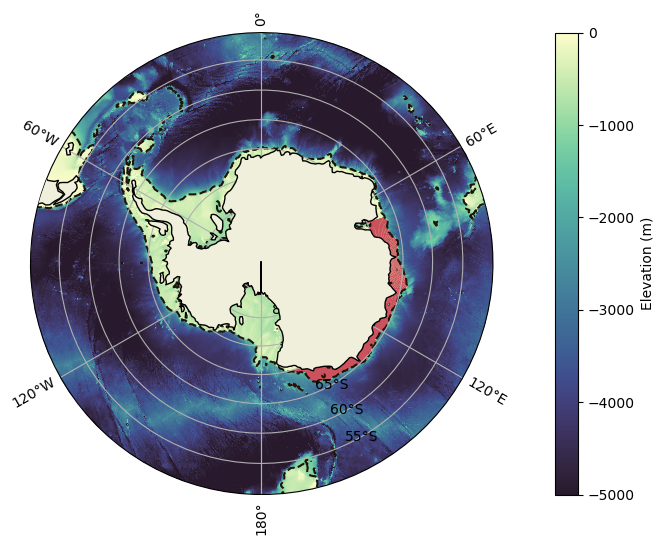

In [10]:
region.plot_region()

In [11]:
meop=MEOP(extent)

In [12]:
meop.load_profiles()

  0%|          | 0/363 [00:00<?, ?it/s]

100%|██████████| 363/363 [16:03<00:00,  2.65s/it]


In [13]:
meop.grid_profiles(sha_ds_sla.longitude.to_numpy(),sha_ds_sla.latitude.to_numpy())

100%|██████████| 97/97 [00:03<00:00, 29.42it/s]


merging...


Text(0.0, 1.0, '(c)')

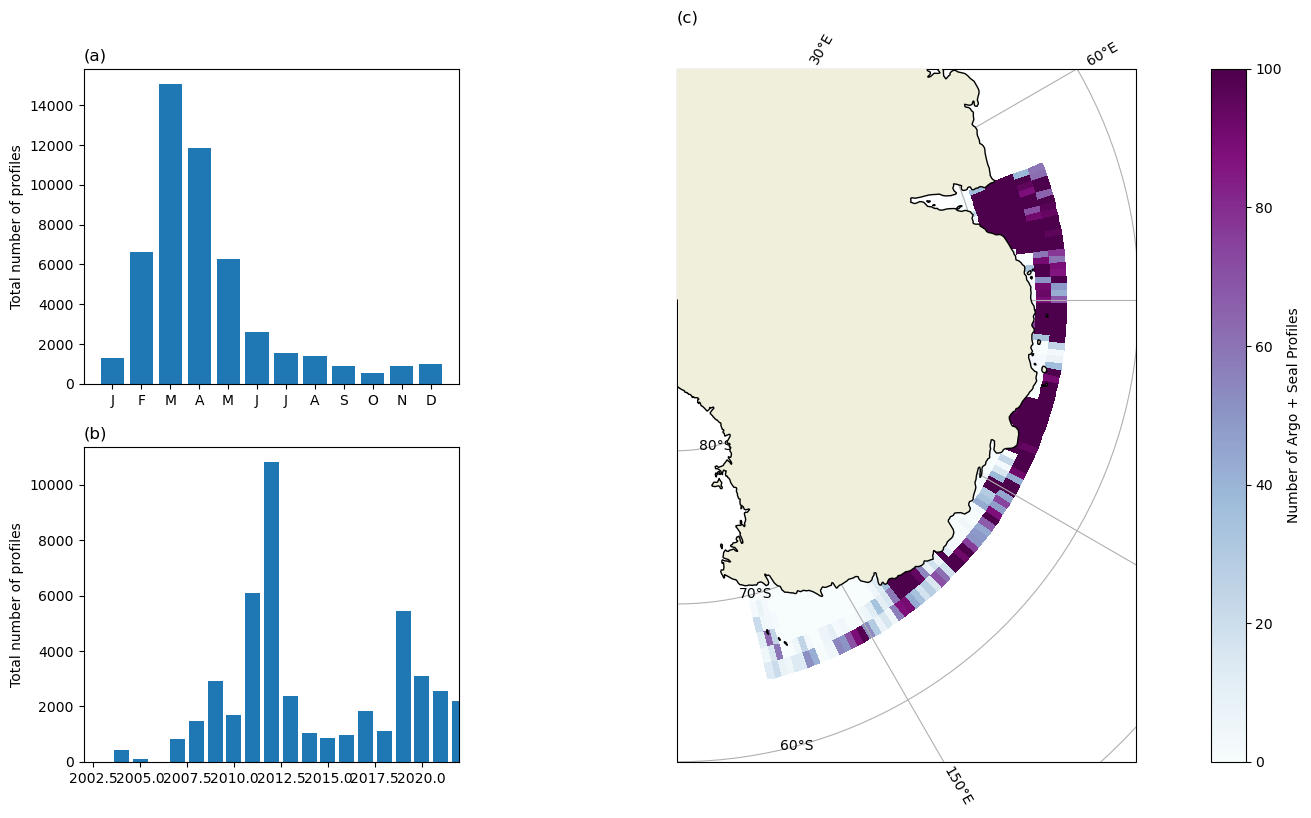

In [14]:
fig = plt.figure(figsize=(16,9))
axs=[]

gs = fig.add_gridspec(2,2,width_ratios=[1,2])

# sha, gpha and sic climatology
axs.append(fig.add_subplot(gs[0, 0]))
axs.append(fig.add_subplot(gs[1, 0]))

monthly_sum = meop.gridded_profiles.profile_cnt.groupby('time.month').sum()
yearly_sum = meop.gridded_profiles.profile_cnt.groupby('time.year').sum()

axs[0].bar(monthly_sum.month,monthly_sum.sum(['latitude','longitude']))
axs[0].set_xticks(np.arange(1,13))
axs[0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
#axs[0].ax.set_xlim([0.5,12.5])
axs[0].set_ylabel('Total number of profiles')
axs[0].set_title('(a)',loc='left')


axs[1].bar(yearly_sum.year,yearly_sum.sum(['latitude','longitude']))
axs[1].set_xlim([2002,2022])
axs[1].set_ylabel('Total number of profiles')
axs[1].set_title('(b)',loc='left')


axs.append(fig.add_subplot(gs[0:2, 1],projection=ccrs.SouthPolarStereo()))

pfns.sp(axs[2],meop.gridded_profiles.profile_cnt.sum(('time')),vmin=0,vmax=100,cbar="Number of Argo + Seal Profiles",cmap='BuPu',cbar_orientation='vertical',extent=[60,180,-90,-60])
axs[2].set_title('(c)',loc='left')


In [15]:
sha_gph_ = xr.merge([sha_ds_sla.where(sha_ds_sla.time > meop.gridded_profiles.time[0],drop=True),
                     meop.gridded_profiles.where(meop.gridded_profiles.time < sha_ds_sla.time[-1],drop=True)])

In [36]:
sha_gph_['profile_gpha'] = 100*(sha_gph_.profile_gph - sha_gph_.profile_gph.mean('time'))

In [39]:
sha_gph_ = region.crop_da(sha_gph_)

# starting resolution 0.5 degrees lat (56km); 1 degree longitude (~47km)
# coarsen by 6x so it's roughly 300km
coarsen_by=4
n_cutoff=6*coarsen_by
sha_gph = sha_gph_.coarsen(latitude=coarsen_by, longitude=coarsen_by, boundary='trim').mean()

In [40]:
n_months_with_gph = (~np.isnan(sha_gph.profile_gpha)).sum('time')
sha_corr = sha_gph.sha.where(n_months_with_gph > n_cutoff, drop = True)
gph_corr = sha_gph.profile_gpha.where(n_months_with_gph > n_cutoff, drop = True)

In [41]:
sice = xr.open_dataset('../Research/data/PROCESSED/nsidc_sea_ice.nc').nsidc_nt_seaice_conc_monthly
regridder = xe.Regridder(sice,sha_gph_.sha.mean('time'),'bilinear')
sice = regridder(sice)
siz = sice.where(sice > 0.15)

sic_cmt = sice.groupby('time.month').mean()
siz_cmt = siz.groupby('time.month').mean()

in_siz = sic_cmt.sel(month=8) > 0.15
in_piz = sice.quantile(0.05,dim='time')>0.15#(sice > 0.15).all(dim='time')
in_miz = in_siz & ~in_piz

In [42]:
sha_gph_['sice']=sice


In [43]:
def cmt_compare(ds,ax1,ax2,ax3):
    
    data_monthly = ds.where(~np.isnan(ds.sha))
    data_monthly_mean = data_monthly.mean(['latitude','longitude'])
    
    # climatology
    cmt = data_monthly.groupby('time.month').mean('time',skipna=True)
    cmt_mean = cmt.mean(['latitude','longitude'])

    def plot_climatology(ax,var,cl,c,ttl,mkr='-'):
        for grp in data_monthly_mean.groupby('time.year'):
            data = grp[1].groupby('time.month').mean()
            ax.plot(data.month,data[var],mkr,label=grp[0],c=cl)
        ax.plot(cmt.month,cmt_mean[var].to_numpy(),'-',c=c)
        ax.set_xticks(np.arange(1,13))
        ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
        ax.set_xlim([0.5,12.5])
        if var == 'sice':
            ax.set_ylim([0,0.5])
        else:
            ax.set_ylim([-3,3])
        ax.set_ylabel(ttl)
        #ax.set_title(ttl,loc='left')
        ax.grid()

    plot_climatology(ax1,'sha',uc.SHA.value[1],uc.SHA.value[0],'SHA (cm)')
    plot_climatology(ax2,'profile_gpha',uc.GPHA.value[1],uc.GPHA.value[0],'GPHA (cm)')
    plot_climatology(ax3,'sice',uc.SICE.value[1],uc.SICE.value[0],'SIC (frac)')


ValueError: Cannot specify both x and y kwargs for line plots.

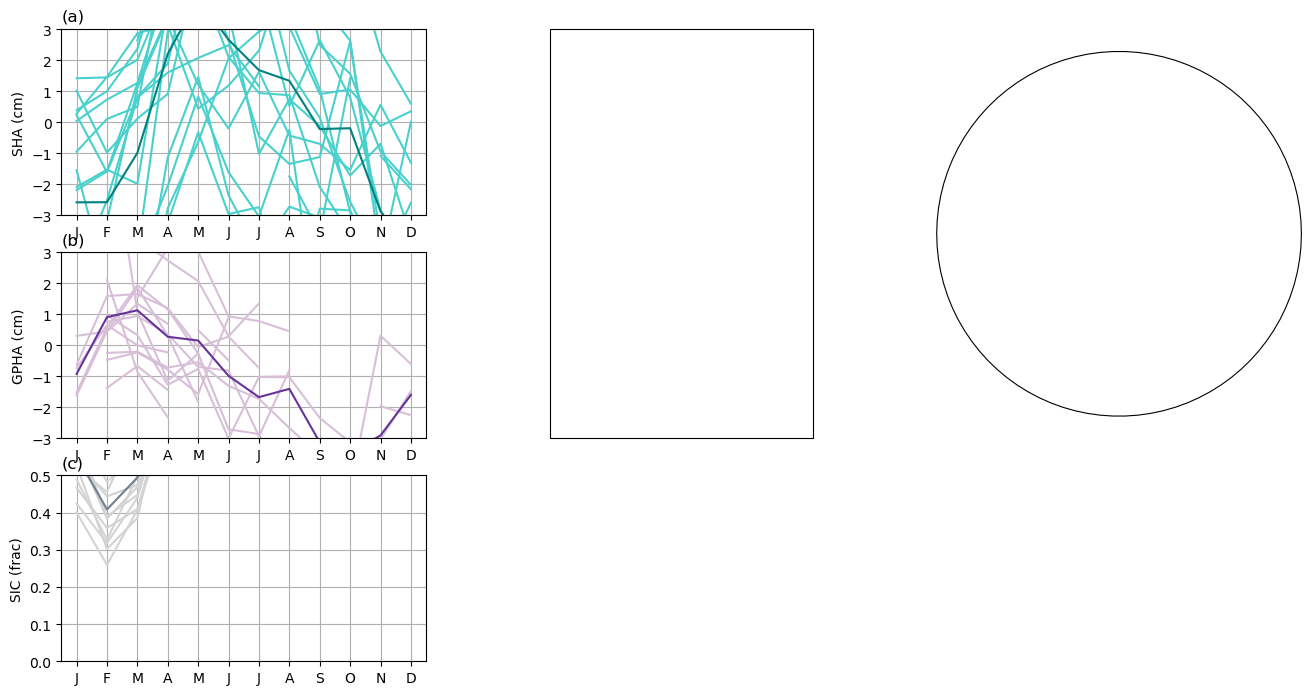

In [44]:
fig = plt.figure(figsize=(16,14))
axs=[]

gs = fig.add_gridspec(5,3)

# sha, gpha and sic climatology
axs.append(fig.add_subplot(gs[0, 0]))
axs.append(fig.add_subplot(gs[1, 0]))
axs.append(fig.add_subplot(gs[2, 0]))

cmt_compare(sha_gph_,axs[0],axs[1],axs[2])
axs[0].set_title('(a)',loc='left')
axs[1].set_title('(b)',loc='left')
axs[2].set_title('(c)',loc='left')

# density and correlation
axs.append(fig.add_subplot(gs[0:2, 1],projection=ccrs.SouthPolarStereo()))
axs.append(fig.add_subplot(gs[0:2, 2],projection=ccrs.SouthPolarStereo()))

pfns.sp(axs[3],sha_gph.profile_cnt.sum(('time')),vmin=0,vmax=300,cbar="Number of Argo + Seal Profiles",cmap='BuPu',cbar_orientation='horizontal',extent=extent)
axs[3].set_title('(d)',loc='left')

# create a mask to hide places with less than 6 profiles
mask6_ = xr.ones_like(n_months_with_gph)
mask6 = mask6_.where(n_months_with_gph<n_cutoff,np.nan)
cmap6 = 'gist_ncar'

pfns.sp(axs[4],xr.corr(sha_corr,gph_corr,dim='time'),cmap=cmocean.cm.balance,cbar='Pearson Correlation',cbar_orientation='horizontal',extent=extent)
mask6.plot(ax=axs[4],transform=ccrs.PlateCarree(),x='longitude',y='latitude',cmap=cmap6,add_colorbar=False)
axs[4].set_title('(e)',loc='left')

# kerbguelen
axs.append(fig.add_subplot(gs[2, 1:4]))

sample_rg = Region('Sample Region', extent)#, max_elevation=-1000)
sample_rg.timeseries_compare(sha_gph,annual=False,fig=fig,ax=axs[5],crop_times=True)
axs[5].set_title('(f)',loc='left')
axs[5].set_ylim([-6,6])


plt.tight_layout()

In [51]:
def cmt_compare(ds,ax1,ax2,ax3):
    
    data_monthly = ds.where(~np.isnan(ds.sha))
    data_monthly_mean = data_monthly.mean(['latitude','longitude'])
    
    # climatology
    cmt = data_monthly.groupby('time.month').mean('time',skipna=True)
    cmt_mean = cmt.mean(['latitude','longitude'])

    def plot_climatology(ax,var,cl,c,ttl,mkr='-'):
        for grp in data_monthly_mean.groupby('time.year'):
            data = grp[1].groupby('time.month').mean()
            ax.plot(data.month,data[var],mkr,label=grp[0],c=cl)
        ax.plot(cmt.month,cmt_mean[var].to_numpy(),'-',c=c)
        ax.set_xticks(np.arange(1,13))
        ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
        ax.set_xlim([0.5,12.5])
        if var == 'sice':
            ax.set_ylim([0,0.5])
        else:
            ax.set_ylim([-3,3])
        ax.set_ylabel(ttl)
        #ax.set_title(ttl,loc='left')
        ax.grid()

    plot_climatology(ax1,'sha',uc.SHA.value[1],uc.SHA.value[0],'SHA (cm)')
    plot_climatology(ax2,'profile_gpha',uc.GPHA.value[1],uc.GPHA.value[0],'GPHA (cm)')
    plot_climatology(ax3,'sice',uc.SICE.value[1],uc.SICE.value[0],'SIC (frac)')


    

Adding row: Mertz
Adding row: Mertz
Adding row: Mertz
Adding row: Mertz
Rendering..


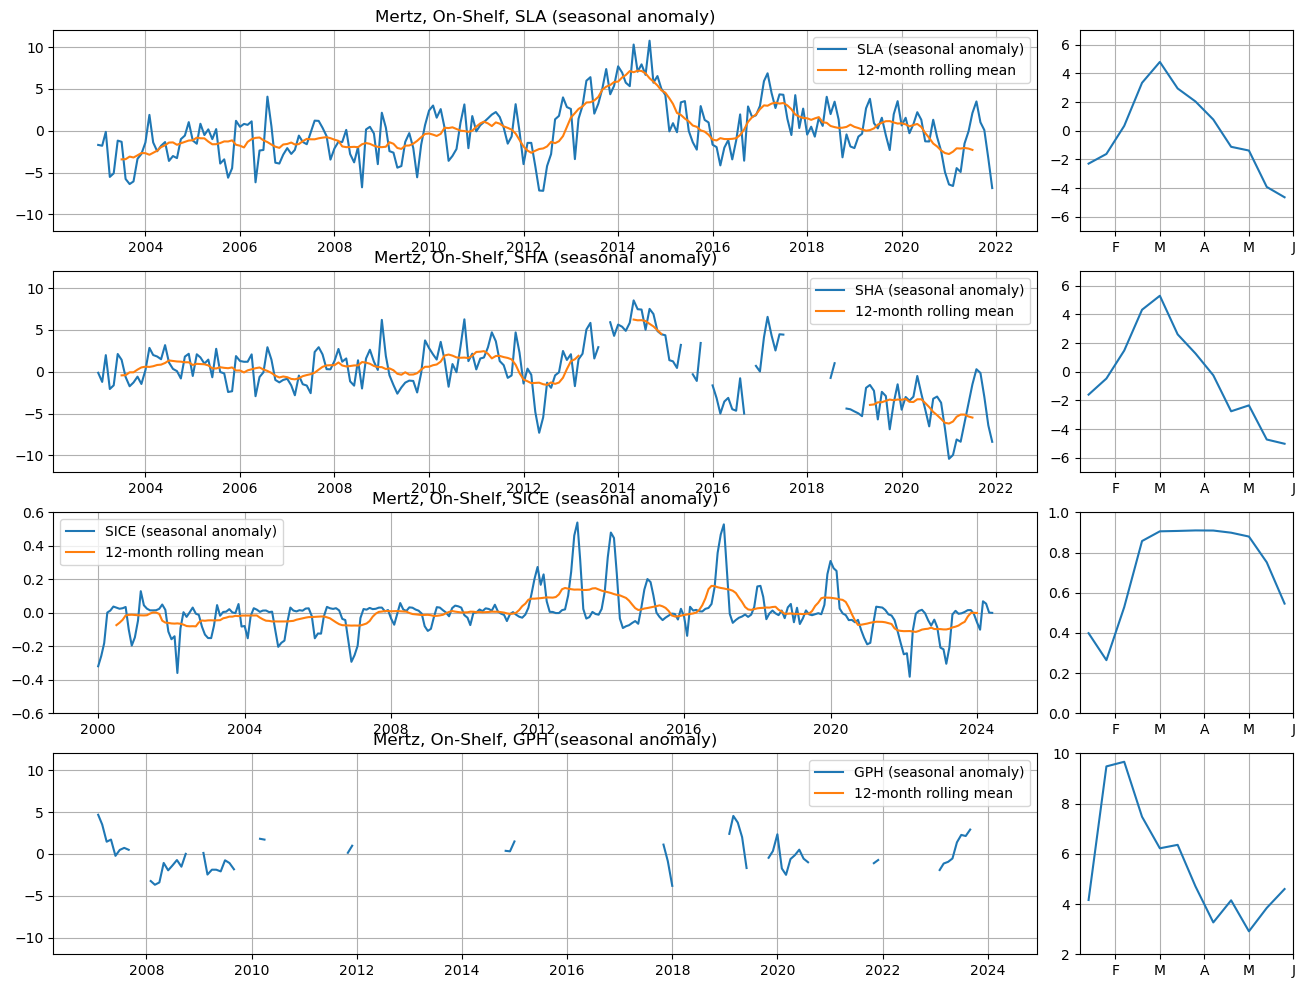

In [ ]:
# compare small mertz area to:
# - extended shelf region (135-145)
# - EA south of Amery
# - whole SO (shelf)
fig = plt.figure(figsize=(16,12))
axs=[]

gs = fig.add_gridspec(4,5)

def add_row_anom(n,var,varname,title,extent,shelf=False,ylim=[-12,12],ylim_cmt=[-7,7]):

    print('Adding row: ' + title)

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if shelf == True:
        region = Region(title, extent, elevation_, min_elevation = -1000)
    else:
        region = Region(title, extent, elevation)


    if varname == 'GPH':
        da = var
    else:
        da = region.crop_da(var).mean(['latitude','longitude'])

    ax = axs[(n*2)]

    cmt = da.groupby('time.month').mean()
    anm = da.groupby('time.month') - cmt
    varname = varname + ' (seasonal anomaly)'

    ax.plot(anm.time,anm,label=varname)
    ax.plot(anm.time,anm.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    shelf_str = 'On' if shelf else 'On and Off'
    ax.set_title(title +', '+shelf_str+'-Shelf, ' + varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    #ax.set_xlim([pd.Timestamp(2012,1,1),pd.Timestamp(2016,12,1)])
    ax.grid()

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])


add_row_anom(0,sha_ds_sla.ssha,'SLA','Mertz',extent,shelf=True)
add_row_anom(1,sha_ds_sla.sha,'SHA','Mertz',extent,shelf=True)
add_row_anom(2,sice,'SICE','Mertz',extent,shelf=True,ylim=[-0.6,0.6],ylim_cmt=[0,1])
add_row_anom(3,profiles_gph*100,'GPH','Mertz',extent,shelf=True,ylim_cmt=[2,10])

print('Rendering..')


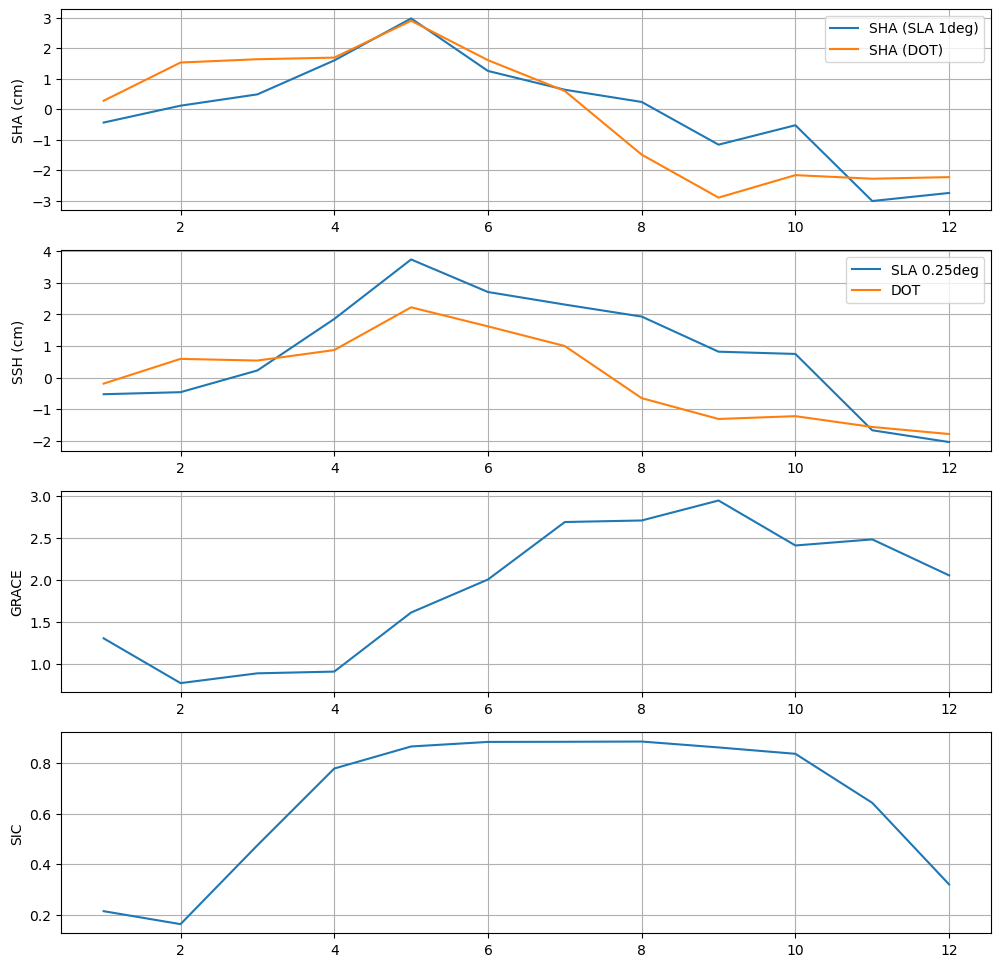

In [26]:
fig,ax = plt.subplots(4,1,figsize=(12,12))

cmt = lambda da: da.groupby('time.month').mean()
months = np.arange(12) + 1

ax[0].plot(months,cmt(sha_sla_).mean(['latitude','longitude']),label='SHA (SLA 1deg)')
ax[0].plot(months,cmt(sha_dot_).mean(['latitude','longitude']),label='SHA (DOT)')
ax[0].set_ylabel('SHA (cm)')
ax[0].legend(loc='best')
ax[0].grid()
# ax.scatter(meop.df.index,meop.df.gph*100,1,marker='x')
ax[1].plot(months,cmt(sla0_).mean(['latitude','longitude']),label='SLA 0.25deg')
ax[1].plot(months,cmt(dot_).mean(['latitude','longitude']),label='DOT')
ax[1].set_ylabel('SSH (cm)')
ax[1].legend(loc='best')
ax[1].grid()

ax[2].plot(months,cmt(lwe_).mean(['latitude','longitude']))
ax[2].set_ylabel('GRACE')
ax[2].grid()

ax[3].plot(months,cmt(sice_).mean(['latitude','longitude']))
ax[3].set_ylabel('SIC')
ax[3].grid()

